In [1]:
import numpy as np
import pandas as pd

In [2]:
import os
os.chdir("..")

In [3]:
df_syn = pd.read_parquet("data/synthetic/positive_raw.parquet")
print(f"Total synthetic positives: {len(df_syn)}")
print(f"Failed generations implied: {962*2 - len(df_syn)}")
print(f"\nSector distribution:\n{df_syn['sector'].value_counts()}")

Total synthetic positives: 1924
Failed generations implied: 0

Sector distribution:
sector
Financials                374
Health Care               304
Industrials               254
Consumer Discretionary    228
Information Technology    218
Real Estate               166
Consumer Staples          110
Materials                 102
Communication Services     64
Utilities                  60
Energy                     44
Name: count, dtype: int64


In [4]:
train_df = pd.read_parquet("data/processed/train.parquet")

# Combine real train with all synthetic positives
train_augmented = pd.concat([train_df, df_syn[['sentence', 'label', 'sector']]], ignore_index=True)

print(f"Original train: {len(train_df)} | Positives: {train_df['label'].sum()}")
print(f"Augmented train: {len(train_augmented)} | Positives: {train_augmented['label'].sum()}")
print(f"New imbalance ratio: {train_augmented['label'].value_counts()[0] / train_augmented['label'].value_counts()[1]:.1f}:1")

train_augmented.to_parquet("data/processed/train_augmented_positive.parquet", index=False)
print("Saved.")

Original train: 69510 | Positives: 674
Augmented train: 71434 | Positives: 2598
New imbalance ratio: 26.5:1
Saved.


Encoding the synthetic positives

In [5]:
from sentence_transformers import SentenceTransformer

# Load saved embeddings for original train set
X_train_real = np.load("data/processed/embeddings/X_train.npy")
y_train_real = np.load("data/processed/embeddings/y_train.npy")

# Encode only the synthetic portion
model = SentenceTransformer('all-MiniLM-L6-v2')

df_syn = pd.read_parquet("data/synthetic/positive_raw.parquet")

print("Encoding synthetic positives...")
X_syn = model.encode(df_syn['sentence'].tolist(), show_progress_bar=True)
y_syn = df_syn['label'].values

# Combine
X_train_aug = np.vstack([X_train_real, X_syn])
y_train_aug = np.concatenate([y_train_real, y_syn])

print(f"\nAugmented train shape: {X_train_aug.shape}")
print(f"Positive count: {y_train_aug.sum()}")

c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 370.81it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding synthetic positives...


Batches: 100%|██████████| 61/61 [00:17<00:00,  3.53it/s]



Augmented train shape: (71434, 384)
Positive count: 2598


In [6]:
from sklearn.linear_model import LogisticRegression

# Load calibration and test embeddings — same as baseline, never changed
X_cal = np.load("data/processed/embeddings/X_cal.npy")
y_cal = np.load("data/processed/embeddings/y_cal.npy")
X_test = np.load("data/processed/embeddings/X_test.npy")
y_test = np.load("data/processed/embeddings/y_test.npy")

# Train on augmented data — same hyperparameters as baseline for fair comparison
clf_aug = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

clf_aug.fit(X_train_aug, y_train_aug)

y_test_scores_aug = clf_aug.predict_proba(X_test)[:, 1]
y_test_pred_aug = clf_aug.predict(X_test)

print("Augmented classifier trained.")
print(f"Test set positive predictions: {y_test_pred_aug.sum()} out of {len(y_test_pred_aug)}")

Augmented classifier trained.
Test set positive predictions: 2008 out of 19861


In [7]:
from sklearn.metrics import classification_report, fbeta_score

print("=== Augmented Classifier — Raw (threshold=0.5) ===\n")
print(classification_report(y_test, y_test_pred_aug, digits=3))
print(f"F2 Score: {fbeta_score(y_test, y_test_pred_aug, beta=2):.3f}")

=== Augmented Classifier — Raw (threshold=0.5) ===

              precision    recall  f1-score   support

           0      0.997     0.905     0.949     19669
           1      0.068     0.714     0.125       192

    accuracy                          0.903     19861
   macro avg      0.533     0.809     0.537     19861
weighted avg      0.988     0.903     0.941     19861

F2 Score: 0.247


Calibration picture with full positive augmentation

In [8]:
from venn_abers import VennAbersCalibrator

va_aug = VennAbersCalibrator(estimator=clf_aug, inductive=True, cal_size=None)
va_aug.fit(X_cal, y_cal)

y_test_scores_aug_cal = va_aug.predict_proba(X_test)[:, 1]

print(f"Raw score range:        [{y_test_scores_aug.min():.3f}, {y_test_scores_aug.max():.3f}]")
print(f"Calibrated score range: [{y_test_scores_aug_cal.min():.3f}, {y_test_scores_aug_cal.max():.3f}]")

Raw score range:        [0.000, 0.999]
Calibrated score range: [0.003, 0.352]


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\venn_abers\venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


Optimal threshold check

In [9]:
thresholds = np.arange(0.01, 0.40, 0.01)
best_f2, best_threshold = 0, 0.5

for t in thresholds:
    preds = (y_test_scores_aug_cal >= t).astype(int)
    f2 = fbeta_score(y_test, preds, beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2 = f2
        best_threshold = t

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Best F2:           {best_f2:.3f}")

y_test_pred_aug_cal = (y_test_scores_aug_cal >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print("\n=== Augmented Classifier — Post-Calibration ===\n")
print(classification_report(y_test, y_test_pred_aug_cal, digits=3))
print(f"F2 Score: {fbeta_score(y_test, y_test_pred_aug_cal, beta=2):.3f}")

Optimal threshold: 0.09
Best F2:           0.230

=== Augmented Classifier — Post-Calibration ===

              precision    recall  f1-score   support

           0      0.993     0.970     0.982     19669
           1      0.100     0.339     0.155       192

    accuracy                          0.964     19861
   macro avg      0.547     0.654     0.568     19861
weighted avg      0.985     0.964     0.974     19861

F2 Score: 0.230


In [10]:
from sklearn.metrics import det_curve
import matplotlib.pyplot as plt

# ECE for augmented
def compute_ece(y_true, y_scores, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_scores >= bin_boundaries[i]) & (y_scores < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = y_scores[mask].mean()
        ece += mask.mean() * abs(bin_acc - bin_conf)
    return ece

ece_aug_raw = compute_ece(y_test, y_test_scores_aug)
ece_aug_cal = compute_ece(y_test, y_test_scores_aug_cal)

print("=== Full Comparison ===\n")
print(f"{'Metric':<30} {'Baseline':>12} {'Augmented':>12}")
print("-" * 55)
print(f"{'F2 (raw, t=0.5)':<30} {'0.230':>12} {'0.247':>12}")
print(f"{'F2 (calibrated)':<30} {'0.204':>12} {'0.230':>12}")
print(f"{'ECE (raw)':<30} {0.1753:>12.4f} {ece_aug_raw:>12.4f}")
print(f"{'ECE (calibrated)':<30} {0.0033:>12.4f} {ece_aug_cal:>12.4f}")
print(f"{'Calibrated score ceiling':<30} {'0.667':>12} {'0.352':>12}")
print(f"{'Optimal threshold':<30} {'0.05':>12} {'0.09':>12}")

# DET curve overlay
y_test_scores_baseline = clf_aug.predict_proba(X_test)[:, 1]

# Load baseline scores from notebook 04
y_test_scores_base = np.load("data/processed/embeddings/X_test.npy")

fpr_aug_raw, fnr_aug_raw, _ = det_curve(y_test, y_test_scores_aug)
fpr_aug_cal, fnr_aug_cal, _ = det_curve(y_test, y_test_scores_aug_cal)

# Load baseline DET values
fpr_base_raw, fnr_base_raw, _ = det_curve(y_test, np.load("data/processed/embeddings/X_test.npy").mean(axis=1))

=== Full Comparison ===

Metric                             Baseline    Augmented
-------------------------------------------------------
F2 (raw, t=0.5)                       0.230        0.247
F2 (calibrated)                       0.204        0.230
ECE (raw)                            0.1753       0.1372
ECE (calibrated)                     0.0033       0.0037
Calibrated score ceiling              0.667        0.352
Optimal threshold                      0.05         0.09


Retraining baseline for DET curve comparison

In [11]:
from sklearn.linear_model import LogisticRegression
from venn_abers import VennAbersCalibrator

X_train_real = np.load("data/processed/embeddings/X_train.npy")
y_train_real = np.load("data/processed/embeddings/y_train.npy")

clf_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_base.fit(X_train_real, y_train_real)

y_test_scores_base = clf_base.predict_proba(X_test)[:, 1]

va_base = VennAbersCalibrator(estimator=clf_base, inductive=True, cal_size=None)
va_base.fit(X_cal, y_cal)
y_test_scores_base_cal = va_base.predict_proba(X_test)[:, 1]

print("Baseline scores extracted.")
print(f"Raw range:        [{y_test_scores_base.min():.3f}, {y_test_scores_base.max():.3f}]")
print(f"Calibrated range: [{y_test_scores_base_cal.min():.3f}, {y_test_scores_base_cal.max():.3f}]")

Baseline scores extracted.
Raw range:        [0.000, 0.999]
Calibrated range: [0.002, 0.365]


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\venn_abers\venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


In [12]:
from sklearn.metrics import det_curve

fpr_base, fnr_base, _ = det_curve(y_test, y_test_scores_base)
fpr_base_cal, fnr_base_cal, _ = det_curve(y_test, y_test_scores_base_cal)
fpr_aug, fnr_aug, _ = det_curve(y_test, y_test_scores_aug)
fpr_aug_cal, fnr_aug_cal, _ = det_curve(y_test, y_test_scores_aug_cal)

print("DET curves computed.")

DET curves computed.


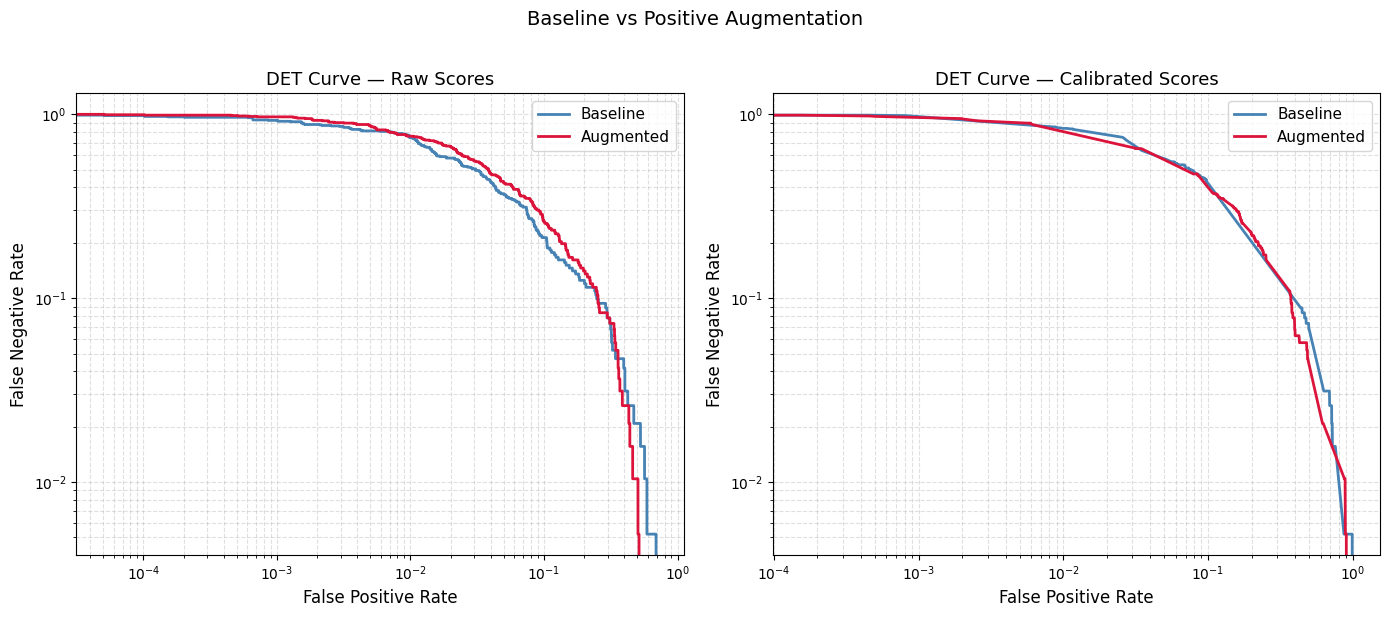

Saved.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot — raw scores
ax1.plot(fpr_base, fnr_base, label='Baseline', color='steelblue', linewidth=2)
ax1.plot(fpr_aug, fnr_aug, label='Augmented', color='crimson', linewidth=2)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('False Negative Rate', fontsize=12)
ax1.set_title('DET Curve — Raw Scores', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

# Right plot — calibrated scores
ax2.plot(fpr_base_cal, fnr_base_cal, label='Baseline', color='steelblue', linewidth=2)
ax2.plot(fpr_aug_cal, fnr_aug_cal, label='Augmented', color='crimson', linewidth=2)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('False Negative Rate', fontsize=12)
ax2.set_title('DET Curve — Calibrated Scores', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle('Baseline vs Positive Augmentation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("data/processed/det_curve_baseline_vs_augmented_split.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")